In [ ]:
from IPython.display import clear_output

! gh auth status > /dev/null || GH_PROMPT_DISABLED=1 gh auth login -w

# Clone and pip install alphagenome_research
! rm -rf ./alphagenome_research \
  && gh repo clone https://github.com/google-deepmind/alphagenome_research

! pip install ./alphagenome_research
clear_output()

In [ ]:
import os
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.visualization import plot_components
from alphagenome_research.model import dna_model

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Flags to improve determinism.
os.environ['XLA_FLAGS'] = ' '.join([
    '--xla_gpu_deterministic_ops',
    '--xla_gpu_enable_scatter_determinism_expander=True',
    '--xla_gpu_enable_triton_gemm=False',
])

# Increase GPU and CPU memory to reduce out of memory errors.
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'

In [ ]:
# Download and load the pre-trained weights from Hugging Face
model = dna_model.create_from_huggingface('all_folds')
clear_output()
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
# Load the sequence data and chromatin states you uploaded
seq_df = pd.read_csv('chr4_sampled_20Mb_block.csv', header=None)
sequence = "".join(seq_df[0].astype(str).values).replace('\n', '')

states_df = pd.read_csv('chr4_sampled_20Mb_chromatin_states.csv', header=None)
chromatin_states = states_df[0].values

# efine the interval based on your filenames
start_coord = 20_000_000
# USE 2**20 (~1.05 Mb) to match AlphaGenome's expected block size
end_coord = start_coord + (2**20)

print(f"Loaded Sequence Length: {len(sequence)} bp")
print(f"Loaded Chromatin States Shape: {chromatin_states.shape}")
print(f"Predicting on interval size: {end_coord - start_coord} bp")

# Create the genomic interval to predict on
interval = genome.Interval('chr4', start_coord, end_coord, strand='+')

# Predict Epigenetic Tracks (which are drivers of Chromatin States)
predictions = model.predict_interval(
    interval,
    requested_outputs={
        dna_model.OutputType.CHIP_HISTONE,
        dna_model.OutputType.ATAC,
        dna_model.OutputType.DNASE,
    },
    ontology_terms=['EFO:0001187'],
)

print("Predictions successfully generated!")

Loaded Sequence Length: 20000000 bp
Loaded Chromatin States Shape: (100000,)
Predicting on interval size: 1048576 bp
Predictions successfully generated!


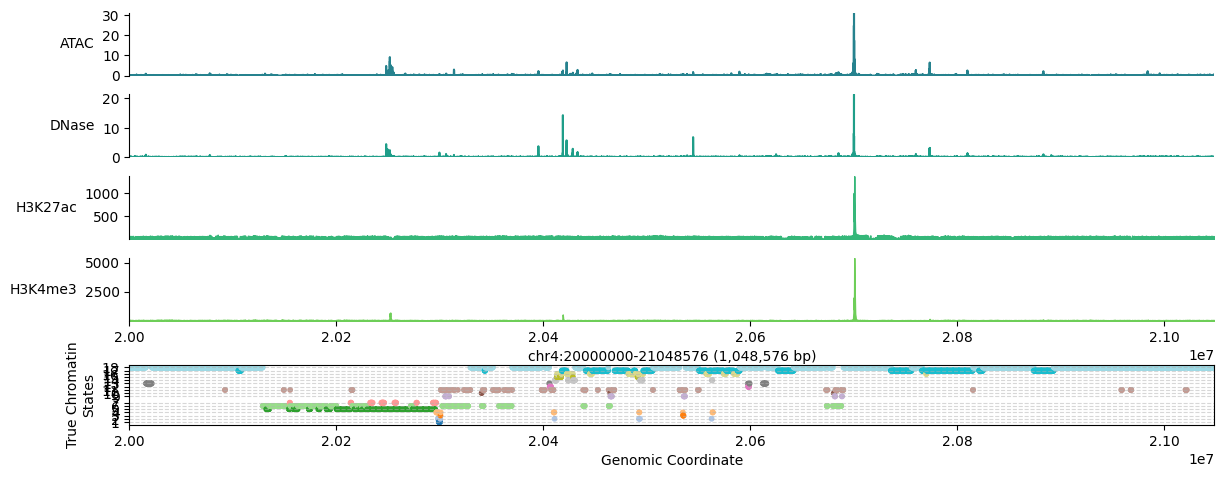

In [ ]:
def _get_colors_hex(cmap_name, n):
  cmap = matplotlib.colormaps[cmap_name]
  return [matplotlib.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)][1:]

colors_hex = _get_colors_hex('viridis', 10)

# Filter out specific tracks often used for ChromHMM / Chromatin State derivation
output_h3k27ac = predictions.chip_histone.filter_tracks(
    (predictions.chip_histone.metadata['histone_mark'] == 'H3K27ac').values)
output_h3k4me3 = predictions.chip_histone.filter_tracks(
    (predictions.chip_histone.metadata['histone_mark'] == 'H3K4me3').values)

# Build the AlphaGenome plot components
components = [
    plot_components.Tracks(
        predictions.atac,
        ylabel_template='ATAC',
        track_colors=colors_hex[3],
        shared_y_scale=True,
    ),
    plot_components.Tracks(
        predictions.dnase,
        ylabel_template='DNase',
        track_colors=colors_hex[4],
        shared_y_scale=True,
    ),
    plot_components.Tracks(
        output_h3k27ac,
        ylabel_template='H3K27ac',
        filled=True,
        track_colors=colors_hex[5],
        shared_y_scale=True,
    ),
    plot_components.Tracks(
        output_h3k4me3,
        ylabel_template='H3K4me3',
        filled=True,
        track_colors=colors_hex[6],
        shared_y_scale=True,
    )
]

# Plot standard predictions
figure = plot_components.plot(
    components,
    interval=interval,
    fig_width=14,
    xlabel='{}:{}-{} ({:,.0f} bp)'.format(
        interval.chromosome, interval.start, interval.end, (interval.end - interval.start)
    ),
)

# Overlay or append your custom Chromatin States
ax = figure.add_axes([0.125, -0.15, 0.775, 0.15]) # [left, bottom, width, height]

# Figure out how many chromatin states correspond to the 2**20 window
# Assuming the 100,000 states uniformly cover the 20,000,000 bp block (1 state per 200 bp)
bp_per_state = len(sequence) / len(chromatin_states)
states_in_window = int((2**20) / bp_per_state)
sliced_states = chromatin_states[:states_in_window]

x_coords = np.linspace(interval.start, interval.end, len(sliced_states))
ax.scatter(x_coords, sliced_states, c=sliced_states, cmap='tab20', s=10)
ax.set_ylabel("True Chromatin\nStates")
ax.set_xlabel("Genomic Coordinate")
ax.set_xlim(interval.start, interval.end)
ax.set_yticks(np.unique(sliced_states))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Aligning AlphaGenome bins (128 bp) with Chromatin States (200 bp)...
Aligned Features Shape: (5242, 4)
Aligned Labels Shape:   (5242,)
Training Random Forest Classifier (this may take a minute)...
Predicting states on the test set...
Generating plot...


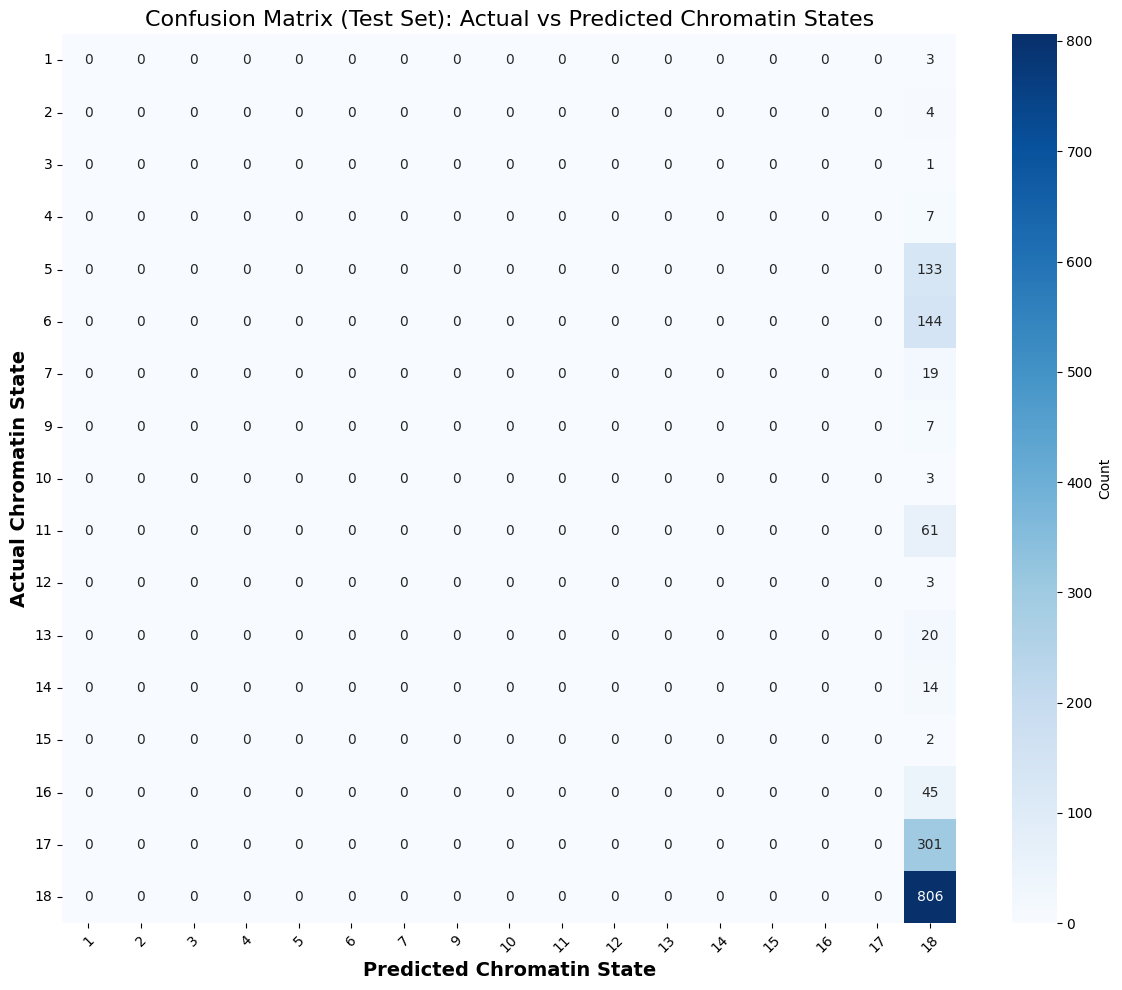

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

print("Aligning AlphaGenome bins (128 bp) with Chromatin States (200 bp)...")

# Get 1D arrays for each track
# (We take the mean across axis=0 in case there are multiple tracks for ATAC/DNase)
# AlphaGenome's output resolution is 128 bp (8192 bins for ~1Mb)
atac_1d = predictions.atac.values.mean(axis=0)
dnase_1d = predictions.dnase.values.mean(axis=0)
h3k27ac_1d = output_h3k27ac.values.mean(axis=0)
h3k4me3_1d = output_h3k4me3.values.mean(axis=0)

# Stack into a single feature matrix of shape (8192, 4)
ag_features = np.column_stack((atac_1d, dnase_1d, h3k27ac_1d, h3k4me3_1d))

# Align Resolutions Using Genomic Coordinates
bp_per_state = 200
bp_per_ag_bin = 128
interval_length = interval.end - interval.start

# Determine exactly how many state bins fit in our 1.048 Mb interval
num_states_in_window = int(interval_length / bp_per_state)
actual_states = chromatin_states[:num_states_in_window]

# For each 200bp state bin, find the corresponding 128bp AlphaGenome bin using the center coordinate
state_centers = np.arange(num_states_in_window) * bp_per_state + (bp_per_state / 2)
ag_bin_indices = (state_centers / bp_per_ag_bin).astype(int)

# Clip to ensure no out-of-bounds errors at the very edge
ag_bin_indices = np.clip(ag_bin_indices, 0, len(atac_1d) - 1)

# Extract the matching AlphaGenome features for each state label
aligned_features = ag_features[ag_bin_indices]

print(f"Aligned Features Shape: {aligned_features.shape}")
print(f"Aligned Labels Shape:   {actual_states.shape}")

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    aligned_features, actual_states, test_size=0.3, random_state=42
)

print("Training Random Forest Classifier (this may take a minute)...")
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print("Predicting states on the test set...")
y_pred = clf.predict(X_test)

# Calculate the confusion matrix
labels = sorted(np.unique(actual_states))
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Generating plot...")
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted Chromatin State', fontsize=14, fontweight='bold')
plt.ylabel('Actual Chromatin State', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix (Test Set): Actual vs Predicted Chromatin States', fontsize=16)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("=== Overall Model Performance ===")
# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("=== Detailed Classification Report ===")
# Generate the report for precision, recall, f1-score, and support
# zero_division=0 prevents warnings if a state was never predicted
report = classification_report(y_test, y_pred, zero_division=0)
print(report)

=== Overall Model Performance ===
Accuracy: 51.24%

=== Detailed Classification Report ===
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00       144
           7       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00        61
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00        20
          14       0.00      0.00      0.00        14
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00        45
          17       0.00      0.00      0.00 